# 13 — SHAP Analysis

Global and local explainability for the final LightGBM classifier (AUC 0.8629) using a 50K stratified sample.

**Input:** `models/lgbm_delay_classifier_final.pkl` · `dataset/FINAL_DATASET.parquet`

**Output:** `models/shap_values_50k_v2.npy` · `models/shap_sample_X_v2.parquet` · `models/shap_sample_y_v2.parquet`

**Top SHAP features:** real_time_turn_gap · inbound_arr_delay_3h · prev_tail_arr_delay · national_hub_delay_2h · origin_delay_rate_7d

In [2]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import shap
import joblib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print(f'SHAP version: {shap.__version__}')
print('✓ Imports ready')

SHAP version: 0.46.0
✓ Imports ready


## Setup: Features + Model

In [3]:
FEATURES = [
    'MONTH', 'DAY_OF_WEEK', 'DEP_HOUR', 'ARR_HOUR', 'IS_HOLIDAY',
    'DISTANCE', 'profit_margin', 'origin_monthly_passengers',
    'origin_temp', 'origin_dew_point', 'origin_pressure',
    'origin_wind_dir', 'origin_wind_speed', 'origin_precip_1hr',
    'origin_weather_severity',
    'dest_temp', 'dest_dew_point', 'dest_pressure',
    'dest_wind_dir', 'dest_wind_speed', 'dest_precip_1hr',
    'dest_weather_severity',
    'airline_delay_rate_30d', 'origin_delay_rate_30d', 'dest_delay_rate_30d',
    'route_delay_rate_30d', 'origin_avg_taxi_out_30d',
    'flight_num_delay_rate_30d', 'origin_hour_delay_rate_30d',
    'carrier_origin_delay_rate_30d', 'dest_hour_delay_rate_30d',
    'airline_delay_rate_7d', 'origin_delay_rate_7d',
    'cascade_score', 'cascade_delay_minutes', 'hours_since_last_delay',
    'hourly_flight_count', 'scheduled_turnaround_buffer', 'tail_flight_num_today',
    'dest_hourly_flight_count',
    'inbound_arr_delay_3h', 'dest_inbound_arr_delay_3h',
    'prev_tail_arr_delay', 'national_hub_delay_2h',
    'OP_UNIQUE_CARRIER', 'ORIGIN', 'DEST', 'airline_cluster_label',
    'origin_pressure_delta_3h', 'dest_pressure_delta_3h',
    'origin_wind_speed_delta_3h', 'dest_wind_speed_delta_3h',
    'day_of_year',
    'origin_dep_delay_rate_1h', 'dest_dep_delay_rate_1h',
    'origin_stress_index', 'real_time_turn_gap',
    'tail_delays_today', 'tail_active_hours',
    'origin_pressure_drop_stress', 'airport_fatigue_index',
]
CAT_FEATURES = ['OP_UNIQUE_CARRIER', 'ORIGIN', 'DEST', 'airline_cluster_label']
TARGET = 'ARR_DEL15'

model = joblib.load('models/lgbm_delay_classifier_final.pkl')
print(f'Model loaded | Features: {len(FEATURES)}')

Model loaded | Features: 61


## Load Test Set + Stratified SHAP Sample

50K stratified sample preserving the test set delay rate for representative explainability.

In [ ]:
flights = pd.read_parquet('dataset/FINAL_DATASET.parquet')
flights['FL_DATE'] = pd.to_datetime(flights['FL_DATE'])
for col in CAT_FEATURES:
    flights[col] = flights[col].astype('category')

test = flights[flights['FL_DATE'] >= '2025-01-01']
X_test = test[FEATURES].copy()
y_test = test[TARGET].copy()

del flights, test
import gc; gc.collect()

print(f'Test set: {X_test.shape[0]:,} rows | Delay rate: {y_test.mean():.3f}')

# Stratified 50K sample
np.random.seed(42)
delayed_idx = y_test[y_test == 1].index
ontime_idx  = y_test[y_test == 0].index
delay_rate  = y_test.mean()

sample_idx = np.concatenate([
    np.random.choice(delayed_idx, size=int(50_000 * delay_rate), replace=False),
    np.random.choice(ontime_idx,  size=int(50_000 * (1 - delay_rate)), replace=False),
])
np.random.shuffle(sample_idx)

X_shap = X_test.loc[sample_idx]
y_shap = y_test.loc[sample_idx]

print(f'SHAP sample: {X_shap.shape[0]:,} rows | Delay rate: {y_shap.mean():.3f}')

Test set: 4,519,126 rows | Delay rate: 0.230
SHAP sample: 49,999 rows | Delay rate: 0.230


## Compute SHAP Values

In [5]:
import time

start = time.time()
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)
elapsed = time.time() - start

if isinstance(shap_values, list):
    shap_values = shap_values[1]

print(f'SHAP values shape: {shap_values.shape}')
print(f'Computation time: {elapsed/60:.1f} minutes')
print(f'Base rate (expected value): {explainer.expected_value}')

SHAP values shape: (49999, 61)
Computation time: 22.5 minutes
Base rate (expected value): -0.3670924519707588


## Global Feature Importance

Mean absolute SHAP value per feature — model-level explanation of what drives delay predictions.

In [6]:
shap_importance = pd.DataFrame({
    'feature': FEATURES,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0),
}).sort_values('mean_abs_shap', ascending=False)

print('SHAP Global Feature Importance (Top 20):')
print('-' * 50)
for _, row in shap_importance.head(20).iterrows():
    bar = '█' * int(row['mean_abs_shap'] / shap_importance['mean_abs_shap'].max() * 40)
    print(f"  {row['feature']:<40} {row['mean_abs_shap']:.4f}  {bar}")

SHAP Global Feature Importance (Top 20):
--------------------------------------------------
  real_time_turn_gap                       0.7733  ████████████████████████████████████████
  scheduled_turnaround_buffer              0.2756  ██████████████
  prev_tail_arr_delay                      0.2743  ██████████████
  dest_inbound_arr_delay_3h                0.2523  █████████████
  airport_fatigue_index                    0.1557  ████████
  ORIGIN                                   0.1062  █████
  OP_UNIQUE_CARRIER                        0.1027  █████
  flight_num_delay_rate_30d                0.1023  █████
  DEST                                     0.0962  ████
  DEP_HOUR                                 0.0846  ████
  tail_delays_today                        0.0819  ████
  origin_dep_delay_rate_1h                 0.0801  ████
  tail_flight_num_today                    0.0732  ███
  origin_delay_rate_30d                    0.0704  ███
  inbound_arr_delay_3h                     0.0643  ███

## Beeswarm Plot

Shows both direction and magnitude of each feature's impact across all 50K samples.

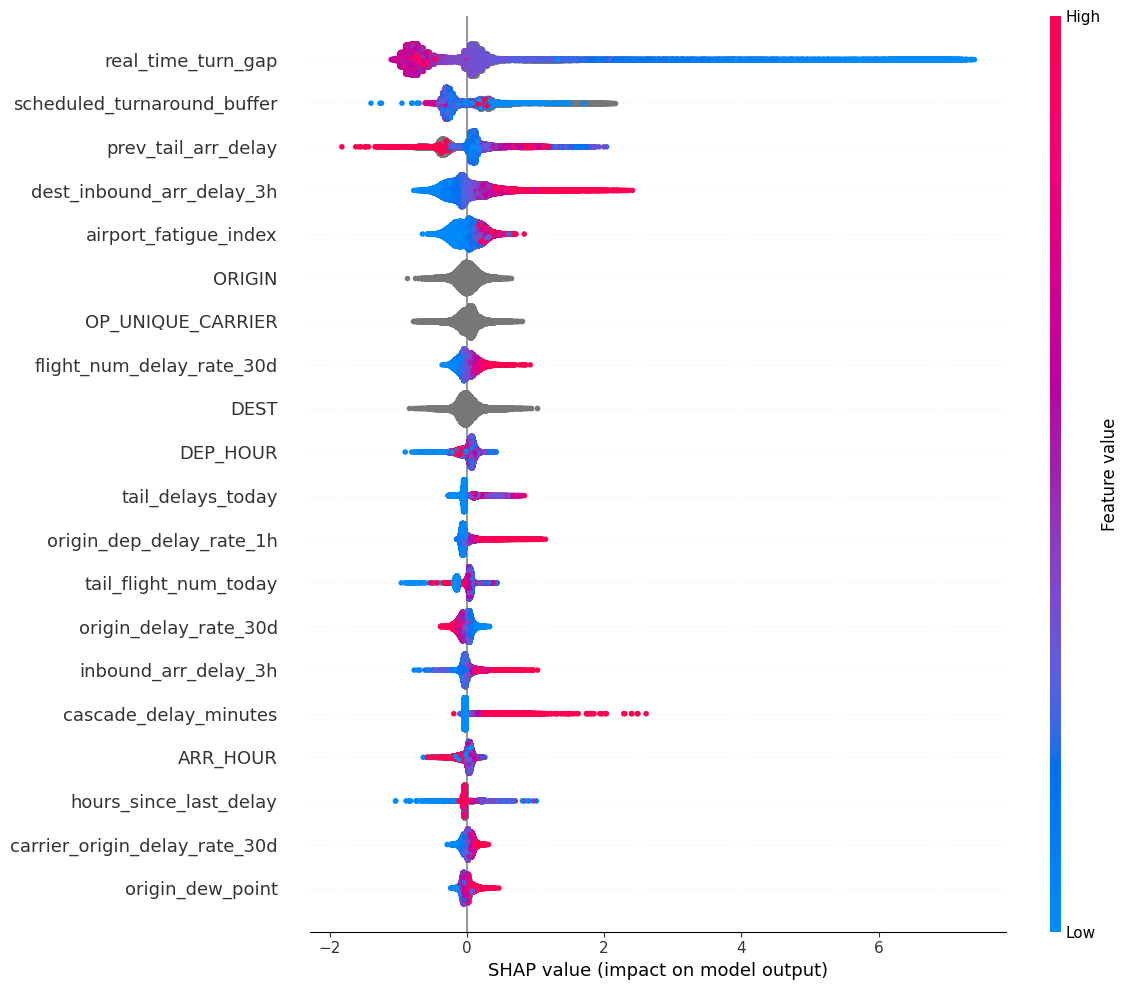

In [7]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=FEATURES,
    max_display=20,
    show=True,
    plot_size=(12, 10),
)

## Dependence Plots

Interaction effects between top features.

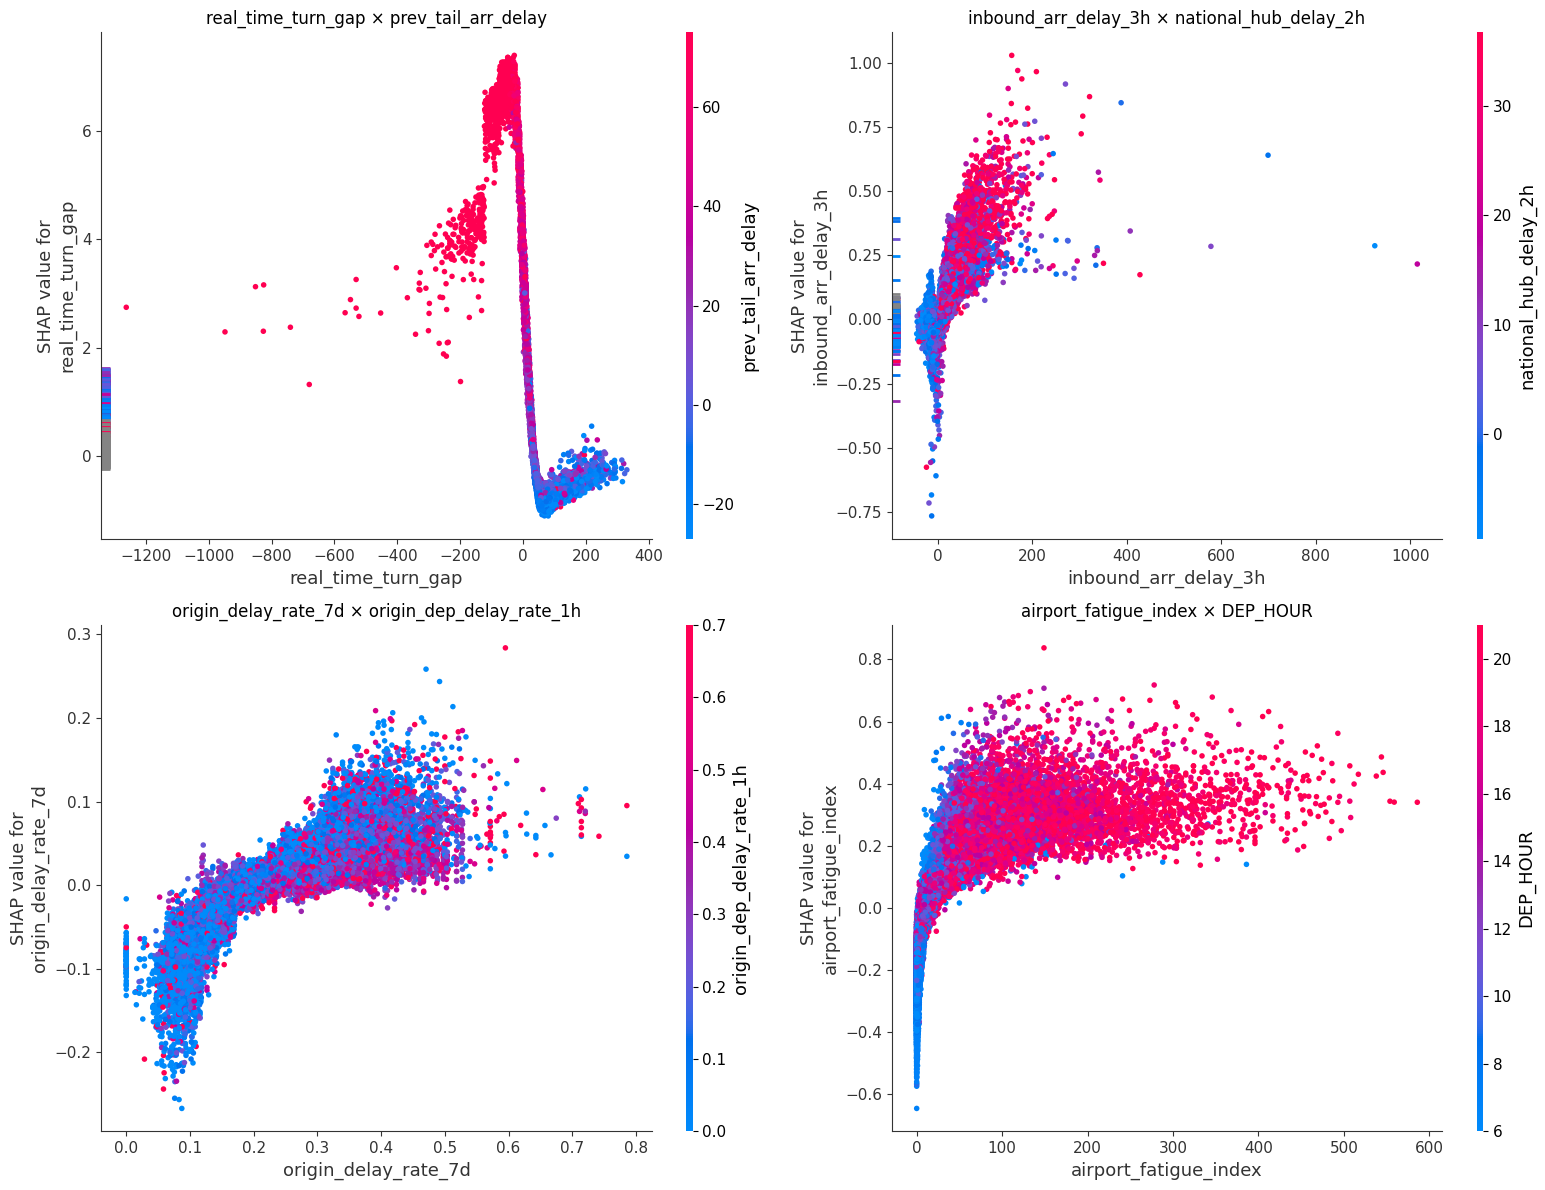

✓ Dependence plots saved


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

shap.dependence_plot(
    'real_time_turn_gap', shap_values, X_shap,
    interaction_index='prev_tail_arr_delay',
    ax=axes[0, 0], show=False,
)
axes[0, 0].set_title('real_time_turn_gap × prev_tail_arr_delay')

shap.dependence_plot(
    'inbound_arr_delay_3h', shap_values, X_shap,
    interaction_index='national_hub_delay_2h',
    ax=axes[0, 1], show=False,
)
axes[0, 1].set_title('inbound_arr_delay_3h × national_hub_delay_2h')

shap.dependence_plot(
    'origin_delay_rate_7d', shap_values, X_shap,
    interaction_index='origin_dep_delay_rate_1h',
    ax=axes[1, 0], show=False,
)
axes[1, 0].set_title('origin_delay_rate_7d × origin_dep_delay_rate_1h')

shap.dependence_plot(
    'airport_fatigue_index', shap_values, X_shap,
    interaction_index='DEP_HOUR',
    ax=axes[1, 1], show=False,
)
axes[1, 1].set_title('airport_fatigue_index × DEP_HOUR')

plt.tight_layout()
plt.savefig('models/shap_dependence_plots_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Dependence plots saved')

## Local Explanations — Waterfall Plots

Individual flight predictions explained: highest risk, borderline, and lowest risk cases.

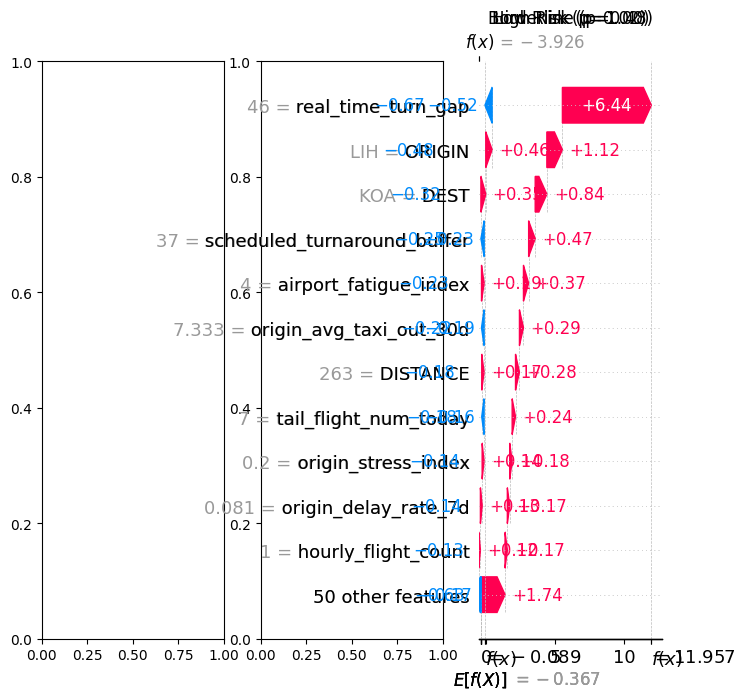

✓ Waterfall plots saved


In [9]:
probs = model.predict_proba(X_shap)[:, 1]

# High risk delayed flight
delayed_mask = y_shap == 1
high_risk_idx = np.where(delayed_mask)[0][probs[delayed_mask].argmax()]

# Low risk on-time flight
ontime_mask = y_shap == 0
low_risk_idx = np.where(ontime_mask)[0][probs[ontime_mask].argmin()]

# Borderline case
borderline_mask = (probs > 0.45) & (probs < 0.55)
borderline_idx = np.where(borderline_mask)[0][0] if borderline_mask.any() else high_risk_idx

fig, axes = plt.subplots(1, 3, figsize=(24, 8))

for ax, idx, title in [
    (axes[0], high_risk_idx,   f'High Risk (p={probs[high_risk_idx]:.2f})'),
    (axes[1], borderline_idx,  f'Borderline (p={probs[borderline_idx]:.2f})'),
    (axes[2], low_risk_idx,    f'Low Risk (p={probs[low_risk_idx]:.2f})'),
]:
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[idx],
            base_values=explainer.expected_value,
            data=X_shap.iloc[idx],
            feature_names=FEATURES,
        ),
        max_display=12,
        show=False,
    )
    plt.title(title)

plt.tight_layout()
plt.savefig('models/shap_waterfall_examples.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Waterfall plots saved')

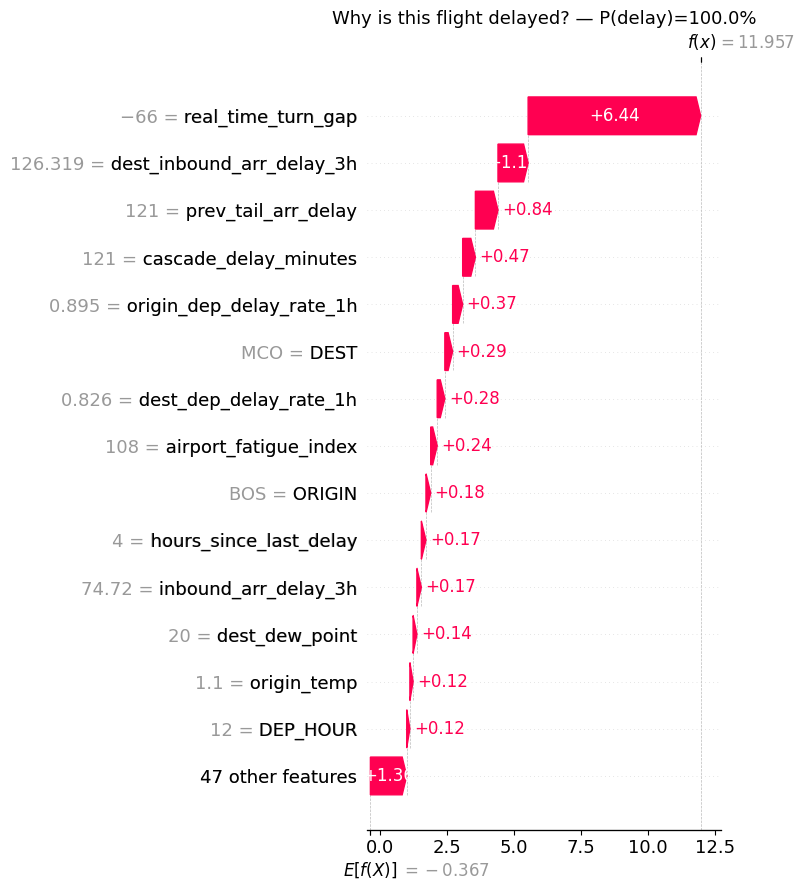

✓ Saved shap_waterfall_high_risk.png


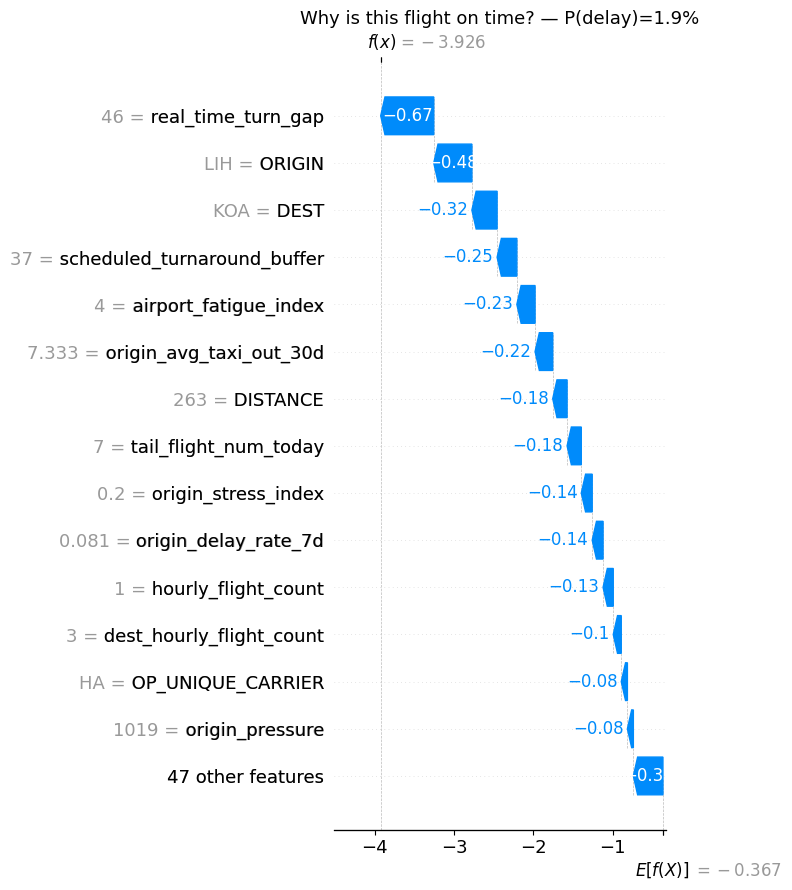

✓ Saved shap_waterfall_low_risk.png


In [11]:
probs = model.predict_proba(X_shap)[:, 1]

# High risk — highest probability delayed flight
delayed_mask = y_shap == 1
high_risk_idx = np.where(delayed_mask)[0][probs[delayed_mask].argmax()]

# Low risk — lowest probability on-time flight
ontime_mask = y_shap == 0
low_risk_idx = np.where(ontime_mask)[0][probs[ontime_mask].argmin()]

# High risk waterfall
plt.figure(figsize=(12, 8))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[high_risk_idx],
        base_values=explainer.expected_value,
        data=X_shap.iloc[high_risk_idx],
        feature_names=FEATURES,
    ),
    max_display=15,
    show=False,
)
plt.title(f'Why is this flight delayed? — P(delay)={probs[high_risk_idx]*100:.1f}%', fontsize=13)
plt.tight_layout()
plt.savefig('models/shap_waterfall_high_risk.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved shap_waterfall_high_risk.png')

# Low risk waterfall
plt.figure(figsize=(12, 8))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[low_risk_idx],
        base_values=explainer.expected_value,
        data=X_shap.iloc[low_risk_idx],
        feature_names=FEATURES,
    ),
    max_display=15,
    show=False,
)
plt.title(f'Why is this flight on time? — P(delay)={probs[low_risk_idx]*100:.1f}%', fontsize=13)
plt.tight_layout()
plt.savefig('models/shap_waterfall_low_risk.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved shap_waterfall_low_risk.png')

## Save SHAP Artifacts

In [10]:
np.save('models/shap_values_50k.npy', shap_values)
X_shap.to_parquet('models/shap_sample_X.parquet')
y_shap.to_frame().to_parquet('models/shap_sample_y.parquet')

print(f'✓ SHAP values saved: models/shap_values_50k.npy {shap_values.shape}')
print(f'✓ SHAP sample X saved: models/shap_sample_X.parquet {X_shap.shape}')
print(f'✓ SHAP sample y saved: models/shap_sample_y.parquet {y_shap.shape}')

✓ SHAP values saved: models/shap_values_50k.npy (49999, 61)
✓ SHAP sample X saved: models/shap_sample_X.parquet (49999, 61)
✓ SHAP sample y saved: models/shap_sample_y.parquet (49999,)
